In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from pprint import pprint

from functools import partial

import numpy as np
from sklearn.preprocessing import scale
# import sklearn.metrics as metrics
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import matplotlib.animation as ani

import mlgrad.models as models
import mlgrad.regr as regr
import mlgrad.cls as cls
import mlgrad.pca as pca
import mlgrad.plots as plots
import mlgrad.funcs as funcs
import mlgrad.funcs2 as funcs2
import mlgrad.loss as loss
import mlgrad.gd as gd
import mlgrad.smooth as smooth
import mlgrad.inventory as inventory
from mlgrad.af import averaging_function
import mlgrad.avragg as avragg

import rampy
import pybaselines
import random

from irsa import io
from irsa.preprocess import despike, utils
import irsa.widgets as widgets
import irsa.spectra as spectra
import irsa.io as io

import scipy.special as special

import copy

import ipywidgets
from IPython.display import display

import sys
print(sys.version)

# %matplotlib widget

3.13.12 (main, Feb  4 2026, 15:06:39) [GCC 15.2.0]


In [2]:
path = f"/home/intellimath/YD/repos/spectra/14"
options = {}
dd = {}
# widgets.load_spectra(path, dd, options)

In [3]:
# dd = io.load_spectra(path, {"вид_бактерий":"STR", "отсечки_по_молекулярной_массе":"less30more10"})
# dd = io.load_spectra(path, {"штамм_бактерий":["36", "95", "B", "C"], "тип_измерения_спектров":["SE"],
#                             "отсечки_по_молекулярной_массе": ["less100"],})
# dd = io.load_spectra(path, {"штамм_бактерий":["36", "95"], #"A", "B", "C", "D"], 
#                              "отсечки_по_молекулярной_массе": "less100",
#                              "тип_измерения_спектров":"SE"})
# dd = io.load_spectra(path, {})
dd = io.load_spectra(path, {"вид_бактерий":["SA", "SS", "SH"], 
                            "номер_цикла":["14"], 
                            "номер_эксперимента_в_цикле":["2", "4"],
                            # "отсечки_по_молекулярной_массе": ["more100"],
                            
                           }, verbose=False)

In [4]:
dd.align_bottom()
dd.crop(400)

In [5]:
# dd.plot_sigma_mu(1.0, n_component=100)

In [6]:
# dd.select_for_exclusion(sigma_mu=0.15)
dd.exclude_by_default(sigma_mu=0.15)

In [7]:
# dd.exclude_selected()

In [8]:
dd.drop_zeros_spectrum()
dd.drop_notfinite()
dd.drop_empty()

In [9]:
dd.plot_spectra(True, "wh", tau2_smooth=1, n_component=None, ms=1, lw=0)

interactive(children=(Dropdown(description='Spectra key:', layout=Layout(width='75%'), options=('20260303_SH_1…

In [10]:
dd.isfinite()

In [11]:
# dd.select_baselines(tau2=1.0e6, tau2_smooth=0.0, func=funcs.Step(0.00, eps=0.001), func2=funcs.Step(0.00, 0.001))

In [12]:
# dd.plot_sigma_mu(n_component=None)

In [13]:
dd2 = spectra.SpectraCollection()
for key, sp in dd.spectra.items():
    dd2[key] = sp.robust_averaging(tau=3.5)

In [14]:
dd2.isfinite()

In [15]:
dd2.drop_notfinite()

In [16]:
dd2.drop_zeros_spectrum()

In [17]:
dd2.plot_mu_sigma()

interactive(children=(Dropdown(description='Spectra key:', layout=Layout(width='75%'), options=('20260303_SH_1…

In [18]:
dd2.plot_spectra(0.0)

interactive(children=(Dropdown(description='Spectra key:', layout=Layout(width='75%'), options=('20260303_SH_1…

In [19]:
# dd2.scale_by_mean(scale=10.0)

In [20]:
# dd2.select_baselines(tau2=1.0e6, func=funcs.Step(0.00, 0.001), 
#                      # func2=funcs.Step(0.00, 0.001),
#                      tau2_smooth=0.0) #, func2_e=inventory.relative_abs_max)

In [21]:
# dd2.isfinite()

In [22]:
# dd2.select_for_exclusion()

In [23]:
# dd2.apply(lambda x, y: np.log(y+1))

In [24]:
# dd2.apply(lambda x, y: y+(y.max()-y.min())/(x.max()-x.min())*(x-x.min()))

In [25]:
# dd2.apply(lambda x, y: np.exp(y)-1)

In [26]:
# dd2.scale_by_max()
# dd2.scale_by_mean()

In [27]:
# dd2.plot_spectra(n_component=0.99)

In [28]:
# dd2.plot_logscale()

In [29]:
# dd2.loglog()

In [30]:
# dd2.logscale()

In [31]:
# dd2.smooth(method="irsa", tau2=1.0)

In [32]:
# dd2.plot_smoothed(tau2=1.0, func=None, xrange=(700,1000))
# dd2.plot_smoothed(tau2=1.0, func=funcs.SoftAbs_Sqrt(1.0).derivative_div_array, xrange=(700,1000))
# dd2.plot_smoothed(tau2=1.0, func=funcs.SoftAbs_Sqrt(0.001).derivative_div_array, 
#                   func2=funcs.SoftAbs_Sqrt(0.001).derivative_div_array, xrange=(700,1100)) #, func2_e=inventory.relative_abs_max)

In [33]:
# dd2.select_baselines(tau2=1.0e6, tau2_smooth=0.0, func=funcs.Step(0.00, eps=0.001), 
#                      # func2=funcs.Step(0.1, eps=0.001), 
#                      d=4)

dd2.select_baselines(tau2=1.0e3, tau2_smooth=0.0, 
                     # func=smooth.func_aspls,
                     func=funcs.RStep(0.001, eps=0.001), 
                     # func2=funcs.RStep(0.0, eps=0.001),
                     func2_e=inventory.relative_abs_max,
                     d=2)

# dd2.select_baselines(tau2=1.0e6, func=smooth.func_aspls, func2_e=inventory.relative_abs_max)

interactive(children=(Dropdown(description='Spectra key:', layout=Layout(width='75%'), options=('20260303_SH_1…

In [34]:
def subtract_baseline(x, y, tau2=1.0e3):
    bl, dd = smooth.whittaker_smooth_weight_func2(
        y,
        func=funcs.RStep(0.001, eps=0.001),
        # func2=funcs.RStep(0.0, eps=0.001),
        func2_e=inventory.relative_abs_max,
        tau2=tau2, d=2)
    y -= bl
    y /= abs(y).mean()
    return y

dd2.apply(subtract_baseline, inplace=True)

20260303_SH_15__14_4_1_2_super_SE__H2O(HPLC)_
20260303_SH_15__14_4_1_1_super_SE__H2O(HPLC)_
20260303_SH_15__14_4_1_3_super_SE__H2O(HPLC)_
20260303_SA_97__14_4_1_2_super_SE__H2O(HPLC)_
20260303_SA_97__14_4_1_3_super_SE__H2O(HPLC)_
20260303_SA_97__14_4_1_1_super_SE__H2O(HPLC)_
20260303_SS_17__14_4_1_2_super_SE__H2O(HPLC)_
20260303_SS_17__14_4_1_3_super_SE__H2O(HPLC)_
20260303_SS_17__14_4_1_1_super_SE__H2O(HPLC)_
20260217_SA_97__14_2_1_3_super_SE__H2O(HPLC)_
20260217_SA_97__14_2_1_1_super_SE__H2O(HPLC)_
20260217_SA_97__14_2_1_2_super_SE__H2O(HPLC)_
20260217_SH_15__14_2_1_1_super_SE__H2O(HPLC)_
20260217_SH_15__14_2_1_2_super_SE__H2O(HPLC)_
20260217_SH_15__14_2_1_3_super_SE__H2O(HPLC)_
20260217_SS_17__14_2_1_2_super_SE__H2O(HPLC)_
20260217_SS_17__14_2_1_1_super_SE__H2O(HPLC)_
20260217_SS_17__14_2_1_3_super_SE__H2O(HPLC)_


In [35]:
dd2.scale_by_zscore()

In [36]:
dd2.plot_spectra(0)

interactive(children=(Dropdown(description='Spectra key:', layout=Layout(width='75%'), options=('20260303_SH_1…

In [33]:
dd3 = dd2

In [34]:
dd2.plot_topf(tval=0, crop=400, n_peaks=None)

interactive(children=(Dropdown(description='Spectra key:', layout=Layout(width='75%'), options=('20260112_SH_1…

In [35]:
dd3 = dd2.topf(tval=0, crop=400, sub_valleys=False)

In [52]:
dd2.plot_mu_sigma()

interactive(children=(Dropdown(description='Spectra key:', layout=Layout(width='75%'), options=('20260303_SH_1…

In [36]:
dd2.plot_spectra(tau2_smooth=0)

interactive(children=(Dropdown(description='Spectra key:', layout=Layout(width='75%'), options=('20260303_SH_1…

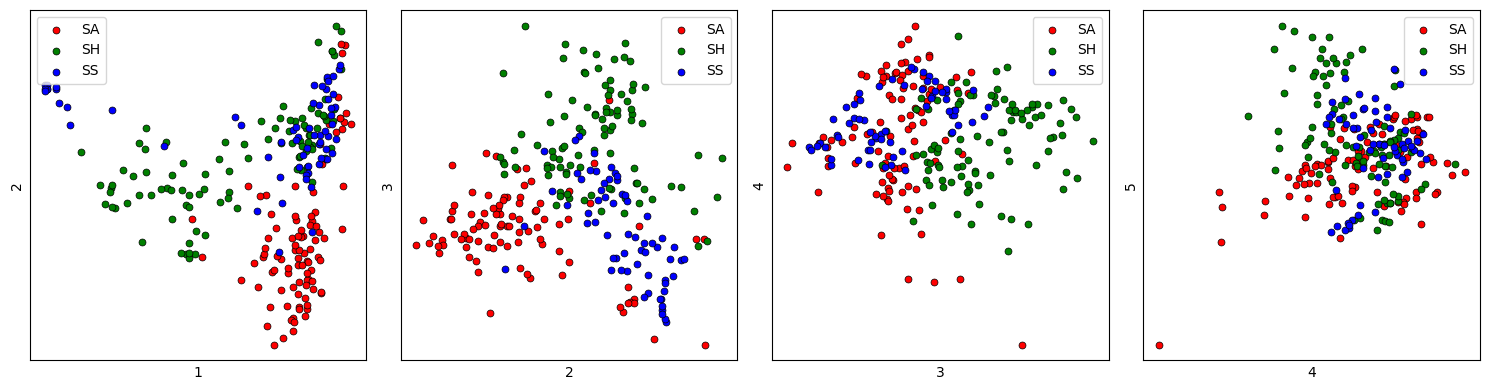

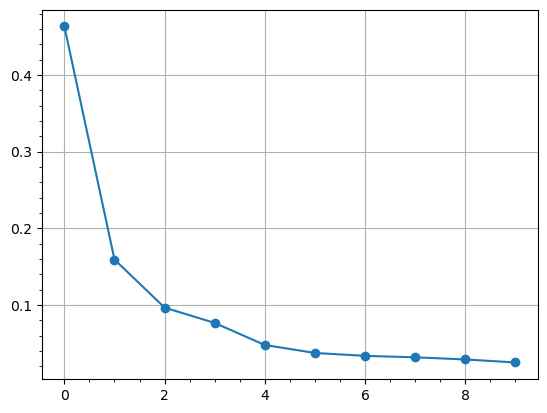

In [37]:
Ys_SA = tuple(dd2.spectra[key].y for key in dd2.keys() if "_SA_" in key)
Ys_SS = tuple(dd2.spectra[key].y for key in dd2.keys() if "_SS_" in key)
Ys_SH = tuple(dd2.spectra[key].y for key in dd2.keys() if "_SH_" in key)
Ys = tuple(dd2.spectra[key].y for key in dd2.keys())
Ys = np.concatenate(Ys, axis=0)
Ys_SA = np.concatenate(Ys_SA, axis=0)
Ys_SH = np.concatenate(Ys_SH, axis=0)
Ys_SS = np.concatenate(Ys_SS, axis=0)
Ns = tuple(len(y) for y in Ys)
c, As, Ls = pca.find_loc_and_pc(Ys, 10)
U = (Ys - c) @ As.T
U_SA = (Ys_SA - c) @ As.T
U_SS = (Ys_SS - c) @ As.T
U_SH = (Ys_SH - c) @ As.T
plt.figure(figsize=(15,4))
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.scatter(U_SA[:,i], U_SA[:,i+1], s=25, c='r', edgecolors='k', linewidth=0.5, label="SA")
    plt.scatter(U_SH[:,i], U_SH[:,i+1], s=25, c='g', edgecolors='k', linewidth=0.5, label="SH")
    plt.scatter(U_SS[:,i], U_SS[:,i+1], s=25, c='b', edgecolors='k', linewidth=0.5, label="SS")
    plt.xlabel(str(i+1))
    plt.ylabel(str(i+2))
    plt.xticks([])
    plt.yticks([])
    plt.legend()
plt.tight_layout()
plt.legend()

# Cs = sum((n*[c] for n,c in zip(Ns,["r","g","b"])), start=[])
plt.show()
plt.plot(Ls/Ls.sum(), marker='o')
plt.grid()
plt.minorticks_on()
plt.show()

In [ ]:
dd2.scale_by_mean()

In [53]:
dd2.save("/home/intellimath/work/spectra/14_2_4", "rm_bl")

In [5]:
d2 = spectra.SpectraCollection()
d2.load("/home/intellimath/work/spectra/14_2_4", "rm_bl")
dd2 = d2

In [51]:
dd2.drop_zeros_spectrum()
dd2.drop_notfinite()

In [ ]:
dd2.plot_spectra()

In [ ]:
dd2.plot_pca_spectra()

In [ ]:
dd2.plot_pca_eigenvals(10)

In [ ]:
d2.plot_spectra_smoothed(tau2=10)

In [38]:
import mlgrad.models as models
import mlgrad.funcs as funcs
import mlgrad.funcs2 as funcs2
import mlgrad.loss as loss

import mlgrad.regr as regr
import mlgrad.af as af

Zs_SS = np.ones(Ys_SS.shape[0])
Zs_SH = np.ones(Ys_SH.shape[0])
Zs_SA = np.ones(Ys_SA.shape[0])

ys = np.concatenate((Ys_SS, Ys_SH, Ys_SA), axis=0)
zs = np.concatenate((Zs_SS, 2*Zs_SH, 3*Zs_SA), axis=0)

ys1 = np.concatenate((Ys_SS,Ys_SH), axis=0)
zs1 = np.concatenate((Zs_SS,-Zs_SH), axis=0)
ys1 = np.ascontiguousarray(ys1)
zs1 = np.ascontiguousarray(zs1)

ys2 = np.concatenate((Ys_SH,Ys_SA), axis=0)
zs2 = np.concatenate((Zs_SH,-Zs_SA), axis=0)
ys2 = np.ascontiguousarray(ys2)
zs2 = np.ascontiguousarray(zs2)

ys3 = np.concatenate((Ys_SA,Ys_SS), axis=0)
zs3 = np.concatenate((Zs_SA,-Zs_SS), axis=0)
ys3 = np.ascontiguousarray(ys3)
zs3 = np.ascontiguousarray(zs3)

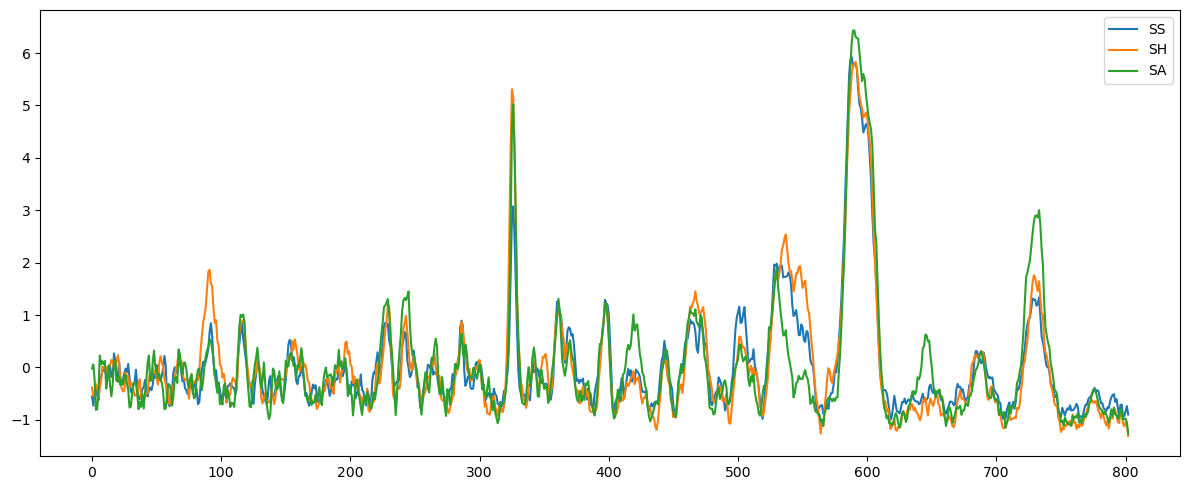

In [39]:
plt.figure(figsize=(12,5))
plt.plot(Ys_SS.mean(axis=0), label="SS")
plt.plot(Ys_SH.mean(axis=0), label="SH")
plt.plot(Ys_SA.mean(axis=0), label="SA")
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
lfm1 = models.LinearFuncModel()
for i in range(21):
    mod = models.SigmaNeuronModel(funcs.Sigmoidal(7.0), ys.shape[1])
    mod.allocate()
    mod.init_param()

    alg1 = regr.regression(ys1, zs1, mod, regnorm=funcs2.AbsoluteNorm(),
                                 normalizer=gd.Masked(mod.n_param, 1.0e-4), 
                                 h=0.001, tau=0.6, n_iter=1000)
    w = accuracy_score(zs1, np.sign(mod.evaluate(ys1)))
    lfm1.add(mod, w)

inventory.normalize(lfm1.weights.asarray())
print(accuracy_score(zs1, np.sign(lfm1.evaluate(ys1))))

0.949685534591195


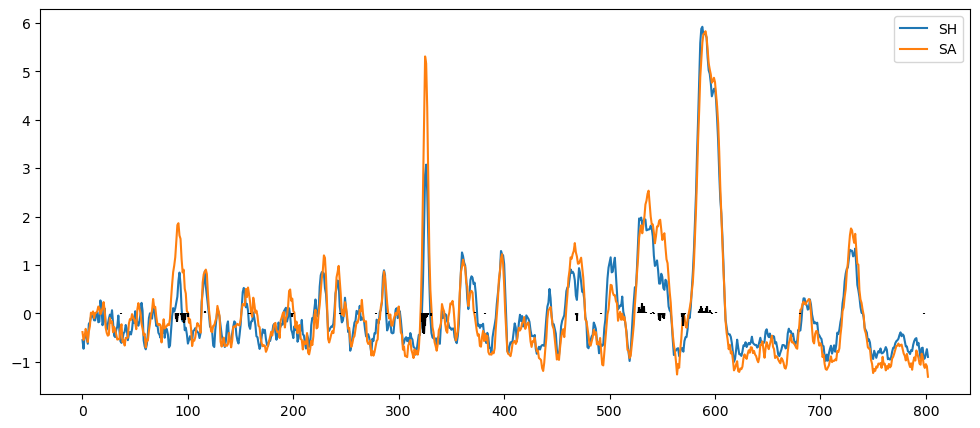

In [43]:
plt.figure(figsize=(12,5))
plt.plot(Ys_SS.mean(axis=0), label="SH")
plt.plot(Ys_SH.mean(axis=0), label="SA")
for mod in lfm1.models:
    param1 = np.asarray(mod.param[1:])
    # print(param1[0])
    param_p = param1.copy()
    param_m = param1.copy()
    param_p[param1 < 0] = 0
    param_m[param1 > 0] = 0
    plt.vlines(range(ys.shape[1]), 10*param_m, 10*param_p, color='k')
plt.legend()
plt.show()

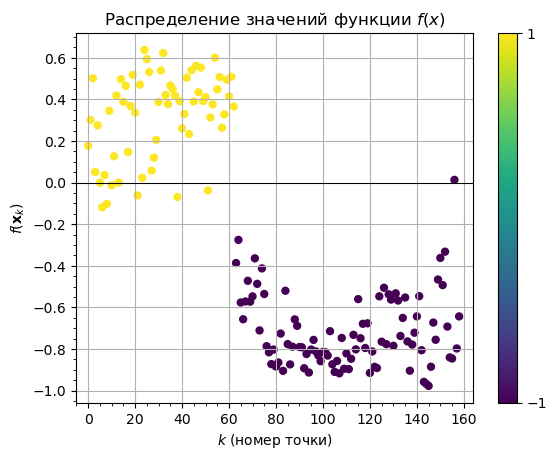

In [44]:
plots.plot_cls_function(lfm1, ys1, zs1)

In [52]:
lfm2 = models.LinearFuncModel()
for i in range(21):
    mod = models.SigmaNeuronModel(funcs.Sigmoidal(7.0), ys.shape[1])
    mod.allocate()
    mod.init_param()

    alg1 = regr.regression(ys2, zs2, mod, regnorm=funcs2.AbsoluteNorm(),
                                 normalizer=gd.Masked(mod.n_param, 1.0e-4), 
                                 h=0.001, tau=0.8, n_iter=1000)
    w = accuracy_score(zs2, np.sign(mod.evaluate(ys2)))
    lfm2.add(mod, w)

inventory.normalize(lfm2.weights.asarray())
print(accuracy_score(zs2, np.sign(lfm2.evaluate(ys2))))

0.9736842105263158


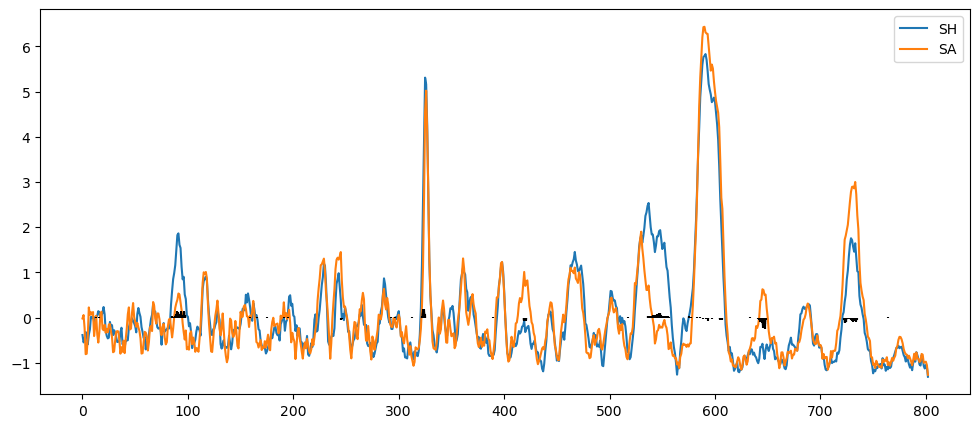

In [53]:
plt.figure(figsize=(12,5))
plt.plot(Ys_SH.mean(axis=0), label="SH")
plt.plot(Ys_SA.mean(axis=0), label="SA")
for mod in lfm2.models:
    param1 = np.asarray(mod.param[1:])
    # print(param1[0])
    param_p = param1.copy()
    param_m = param1.copy()
    param_p[param1 < 0] = 0
    param_m[param1 > 0] = 0
    plt.vlines(range(ys.shape[1]), 10*param_m, 10*param_p, color='k')
plt.legend()
plt.show()

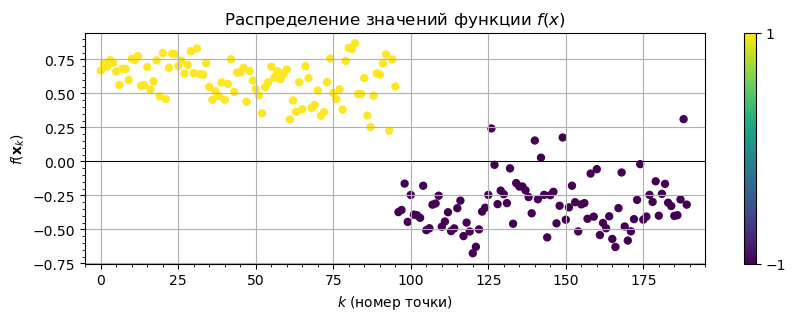

In [54]:
plt.figure(figsize=(10,3))
plots.plot_cls_function(lfm2, ys2, zs2)

In [65]:
lfm3 = models.LinearFuncModel()
for i in range(21):
    mod = models.SigmaNeuronModel(funcs.Sigmoidal(7.0), ys.shape[1])
    mod.allocate()
    mod.init_param()

    alg1 = regr.regression(ys3, zs3, mod, regnorm=funcs2.AbsoluteNorm(),
                                 normalizer=gd.Masked(mod.n_param, 1.0e-4), 
                                 h=0.001, tau=1.7, n_iter=1000)
    w = accuracy_score(zs3, np.sign(mod.evaluate(ys3)))
    lfm3.add(mod, w)

inventory.normalize(lfm3.weights.asarray())
print(accuracy_score(zs3, np.sign(lfm3.evaluate(ys3))))

0.9681528662420382


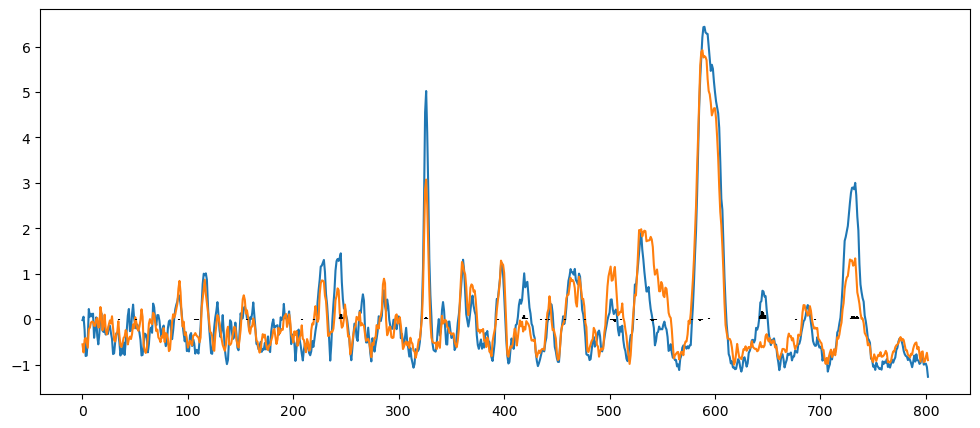

In [66]:
plt.figure(figsize=(12,5))
plt.plot(Ys_SA.mean(axis=0), label="SA")
plt.plot(Ys_SS.mean(axis=0), label="SS")
for mod in lfm3.models:
    param1 = np.asarray(mod.param[1:])
    # print(param1[0])
    param_p = param1.copy()
    param_m = param1.copy()
    param_p[param1 < 0] = 0
    param_m[param1 > 0] = 0
    plt.vlines(range(ys.shape[1]), 10*param_m, 10*param_p, color='k')
plt.show()

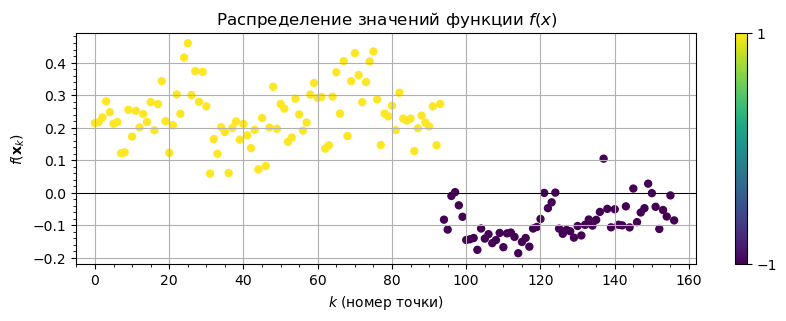

In [67]:
plt.figure(figsize=(10,3))
plots.plot_cls_function(lfm3, ys3, zs3)

253
53
103
108


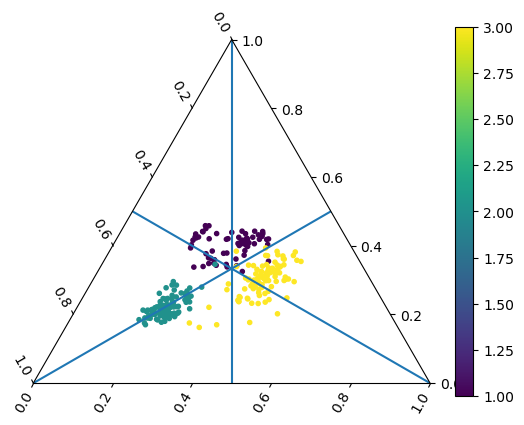

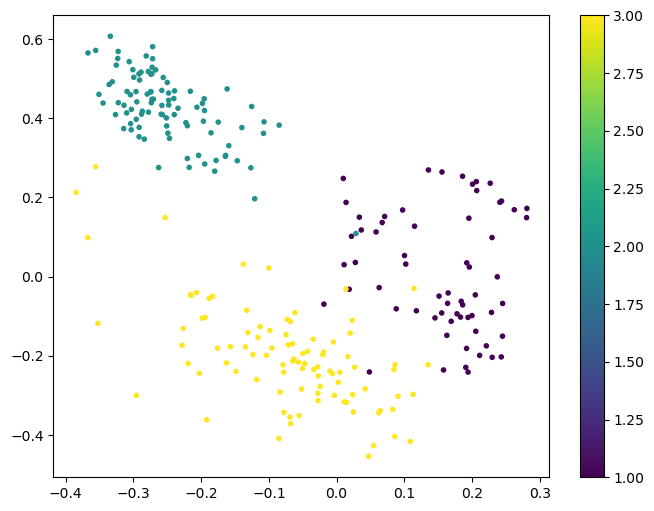

In [68]:
import mpltern
print(len(ys))

ax = plt.subplot(projection="ternary")
Z1 = lfm1.evaluate(ys)
Z2 = lfm2.evaluate(ys)
Z3 = lfm3.evaluate(ys)
Y1 = (1 + (Z1 - Z3) / 2) / 2
Y2 = (1 + (Z2 - Z1) / 2) / 2
Y3 = (1 + (Z3 - Z2) / 2) / 2
Y1[Y1<0] = 0
Y2[Y2<0] = 0
Y3[Y3<0] = 0
print(((Z1>0) & (Z3<0)).sum())
print(((Z2>0) & (Z1<0)).sum())
print(((Z2>0) & (Z3<0)).sum())
# print(Y1)
# print(Y2)
# print(Y3)
C = [(y1,y2,y3) for y1,y2,y3 in zip(Y1,Y2,Y3)]
# cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
cs = ax.scatter(Y1, Y2, Y3, c=zs, s=9)
plt.colorbar(cs)
ax.axline(
    [0.5, 0.0, 0.0],
    [0.5, 0.5, 0.5])
ax.axline(
    [0.0, 0.5, 0.0],
    [0.5, 0.5, 0.5])
ax.axline(
    [0.0, 0.0, 0.5],
    [0.5, 0.5, 0.5])
plt.show()

zz1 = Y1
zz2 = Y2 * np.exp(2j/3 * np.pi)
zz3 = Y3 * np.exp(-2j/3 * np.pi)
C = np.concatenate((Zs_SS, 2*Zs_SH, 3*Zs_SA))
plt.figure(figsize=(8,6))
cs = plt.scatter(np.real(zz1+zz2+zz3), np.imag(zz1+zz2+zz3), s=9, c=C)
plt.colorbar(cs)
plt.show()


## 

# *************************************************************

In [ ]:
import sympy
from sympy import MatrixSymbol, Identity, latex

In [ ]:
from IPython.display import display, Latex

In [ ]:
def latex_matrix(DD):
    n = DD.shape[0]
    s = r"$$\left(\begin{array}{" + n*"l" + "}"
    for i in range(10):
        for j in range(10):
            s += latex(DD[i,j])
            if j < n-1:
                s += r"&"
            else:
                s += r"\\"
    s += r"\end{array}\right)$$"
    # print(s)
    return s

In [ ]:
E = np.eye(10, dtype="i")
D2 = np.diff(E, 2, axis=0)
print(D2)
print(D2.T @ D2)

In [ ]:
w2 = sympy.symarray("w", (10,), )
W2 = np.diag(w2[0:-2])

In [ ]:
DD2 = np.dot(np.dot(D2.T, W2), D2)

In [ ]:
display(Latex(latex_matrix(DD2)))

In [ ]:
D1 = np.diff(np.eye(10, dtype="i"), 1, axis=0, )
print(D1)
print(D1.T @ D1)

In [ ]:
w = sympy.symarray("w", (10,))
W = np.diag(w[:-1])
DD1 = np.dot(np.dot(D1.T, W), D1)

In [ ]:
display(Latex(latex_matrix(DD1)))

In [ ]:
D3 = np.diff(np.eye(10, dtype="i"), 3, axis=0, )
print(D3)
print(D3.T @ D3)

In [ ]:
w3 = sympy.symarray("w", (10,), )
W3 = np.diag(w3[0:-3])

In [ ]:
DD3 = np.dot(np.dot(D3.T, W3), D3)

In [ ]:
display(Latex(latex_matrix(DD3)))

In [ ]:
D4 = np.diff(np.eye(10, dtype="i"), 4, axis=0, )
print(D4)
print(D4.T @ D4)

In [ ]:
w4 = sympy.symarray("w", (10,), )
W4 = np.diag(w4[0:-4])

In [ ]:
DD4 = np.dot(np.dot(D4.T, W4), D4)

In [ ]:
display(Latex(latex_matrix(DD4)))

In [ ]:
import ipywidgets as widgets
import os, time

In [ ]:
buttons = []
for i in range(10):
    buttons.append(widgets.Button(description=f"  The button {i}  "))
box = ipywidgets.Box(buttons)
box.layout = widgets.Layout(flex_flow="row wrap")
box

In [ ]:
fp = widgets.FloatProgress(min=0, max=10, value=0, bar_style="success", description="abcdefghijklmnopqrstuv")
fp.style.width=32
display(fp)
for i in range(11):
    time.sleep(1)
    fp.value=i